In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Load config
import sys
import os
from pathlib import Path
import datajoint as dj
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)

# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

from model_in_the_loop.utils.hydra_utils import load_config,set_env_vars
cfg = load_config()
set_env_vars(cfg)  # set env variables for repo and data paths



/workspace/.venv/lib/python3.12/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


home directory: /gpfs01/euler/User/ssuhai


In [3]:
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.dj_utils as dj_ut
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.rf_mei_test_tables as dj_tab

# import plotter
import thesis.code.plot.plot as plotter
plotter.set_default_params(kind='paper')

FIGURE_PATH = os.path.join(cfg.paths.repo_directory, 'thesis', 'figures', 'analysis_closed_loop_experiments', 'rf_mei_test')
os.makedirs(FIGURE_PATH, exist_ok=True)

In [4]:
print("importing dj_utils")
from thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.dj_utils import *
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.stats_utils as su
import thesis.code.analysis_closed_loop_experiments.rf_mei_test.utils.plot_utils as pu

importing dj_utils


In [5]:
load_dj_config(
    config_file = os.path.join(cfg.paths.home_directory,cfg.paths.dj_config_directory, f'dj_{cfg.DJ.username}_conf.json'),
    schema_name =  f"ageuler_ssuhai_closed_loop_rf_mei"
)

[2025-11-07 10:18:30,429][INFO]: DataJoint is configured from /gpfs01/euler/User/ssuhai/datajoint/dj_ssuhai_conf.json
[2025-11-07 10:18:30,480][INFO]: DataJoint 0.14.6 connected to ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop_rf_mei


In [6]:
prepclassifier_and_activate(
    output_folder = os.path.join(cfg.paths.home_directory,cfg.paths.rgc_output_directory),
)

### closed loop figure traces

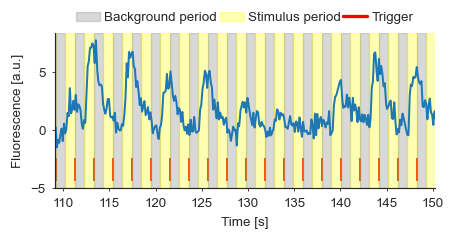

In [7]:
fig,ax = plt.subplots(1,1, figsize= plotter.figsize_from_frac(1/2,1/4))
_ = dj_ut.plot_single_roi_trace_trigger_bg_stim(
        offline2online_roi_id_table=Offline2OnlineRoiId,
        pp_trace_table=PreprocessTraces,
        presentation_table=Presentation,
        stimulus_presentation_info_table=StimulusPresentationInfo,
        stim_type = "on_big",
        ax = ax,
        roi_id=12,
        field_cond2_key={**dj_ut.fetch_all_fields_with_stm("circle")[0], 'cond2': 2},

)


plotter.tight_layout()

# save as svg
fig_name = f"single_roi_trace_trigger_bg_stim_roi12_onbig_cond2.svg"
fig.savefig(os.path.join(FIGURE_PATH, fig_name),format='svg')


### closed loop figure snippets

Dropping 8 rows with is_first_pres_of_stimulus == 1
Filtered rois_snippets_df to columns: ['roi_id', 'stimulus_type', 'single_snippet', 'single_snippet_t0', 'online_roi_id', 'cond2', 'single_snippet_bsl_corrected_median', 'distance']


TypeError: average_df_over_colvalues() got an unexpected keyword argument 'cols_to_keep'

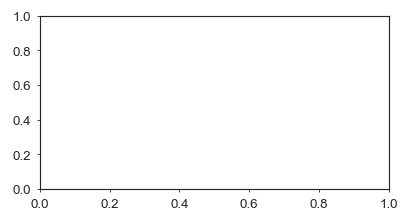

In [9]:
fig,ax = plt.subplots(figsize= plotter.figsize_from_frac(1/2,1/4))

# on_big 12
dj_ut.wrapper_plot_one_roi_ordered_snippets(
    field_key=dj_ut.fetch_all_fields_with_stm("circle")[0],
    roi_id=12,
    bsl_correction_method="median",
    stim_name="on_big",
    plot_kwargs = {} ,
    time_buffer_between_snippets = 15/60,
    ax = ax,
    snippet_vline = True,
    show_legend=True,
    )


plotter.tight_layout()
# # Adjust left margin to make room for the label
# plt.subplots_adjust(left=0.085)  # You may need to adjust this value
fig_name = f"ordered_snippets_onbig_12_field{dj_ut.get_str_from_field_key(dj_ut.fetch_all_fields_with_stm('circle')[0])}.svg"
# plt.savefig(os.path.join(FIGURE_PATH,fig_name),format='svg')


### summary stats and figs  closedloop c)

Using field key: {'experimenter': 'Deja', 'date': datetime.date(2025, 10, 8), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'control'}
Dropping 168 rows with is_first_pres_of_stimulus == 1
Filtered rois_snippets_df to columns: ['roi_id', 'stimulus_type', 'single_snippet', 'single_snippet_t0', 'online_roi_id', 'cond2', 'single_snippet_bsl_corrected_median', 'distance']
Grouping by columns: ['roi_id', 'stimulus_type', 'distance'], reducing df cols over {'cond2', 'online_roi_id', 'single_snippet_t0', 'single_snippet_bsl_corrected_median', 'single_snippet'}
output df col names: ['roi_id', 'stimulus_type', 'distance', 'single_snippet_bsl_corrected_median']
Dropping 168 rows with is_first_pres_of_stimulus == 1
Filtered rois_snippets_df to columns: ['roi_id', 'stimulus_type', 'single_snippet', 'single_snippet_t0', 'online_roi_id', 'cond2', 'single_snippet_bsl_corrected_median', 'distance']
Grouping by columns: ['roi_id', 'stimulus_type', 'distance'], reducing df cols ov

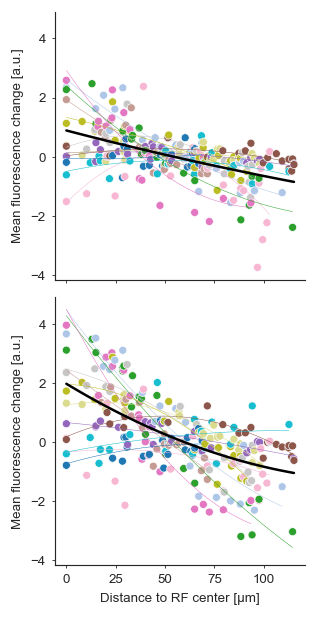

In [ ]:
circle_field_idx = 0
field_key = dj_ut.fetch_all_fields_with_stm("circle")[circle_field_idx]
print(f"Using field key: {field_key}")
fig,axes = plt.subplots(2,1,sharex=True,sharey=True,figsize = (plotter.FULLPAGE_WIDTH / 3, plotter.FULLPAGE_WIDTH * 2/3))
roi_id_list = (Offline2OnlineRoiId() & dict(stim_name="circle") & field_key).fetch("roi_id")

# roi_id_list = 12
ax = dj_ut.wrapper_scatter_response_distance(
    field_key=field_key,
    roi_id_list=roi_id_list,
    bsl_correction_method="median",
    measure="response_mean",
    stimulus_type="on_small",
    ax = axes[0],
    cond2_value=None,
)

# same for on_big but remove legend for ax 0 

ax = dj_ut.wrapper_scatter_response_distance(
    field_key=field_key,
    roi_id_list=roi_id_list,
    bsl_correction_method="median",
    measure="response_mean",
    stimulus_type="on_big",
    ax = axes[1],
    cond2_value=None,)
plotter.tight_layout()
sum_stats_fig_name = f"Summary_stats_on_cells_{dj_ut.get_str_from_field_key(field_key)}.svg"
# plt.savefig(os.path.join(FIGURE_PATH,fig_name),format='svg')


No of fields passed: 3
Nr of rois per field: [21, 16, 5]
Dropping 168 rows with is_first_pres_of_stimulus == 1
Filtered rois_snippets_df to columns: ['roi_id', 'stimulus_type', 'single_snippet', 'single_snippet_t0', 'online_roi_id', 'cond2', 'single_snippet_bsl_corrected_median', 'distance']
Grouping by columns: ['roi_id', 'stimulus_type', 'distance'], reducing df cols over {'single_snippet', 'online_roi_id', 'single_snippet_t0', 'cond2', 'single_snippet_bsl_corrected_median'}
Number of unique groups: 1680
Averaged df over columns: ['single_snippet_bsl_corrected_median'], resulting df has 1680 rows. Differece in rows: 1680
output df col names: ['roi_id', 'stimulus_type', 'distance', 'single_snippet_bsl_corrected_median']
Dropping 320 rows with is_first_pres_of_stimulus == 1
Filtered rois_snippets_df to columns: ['roi_id', 'stimulus_type', 'single_snippet', 'single_snippet_t0', 'online_roi_id', 'cond2', 'single_snippet_bsl_corrected_median', 'distance']
Grouping by columns: ['roi_id', '

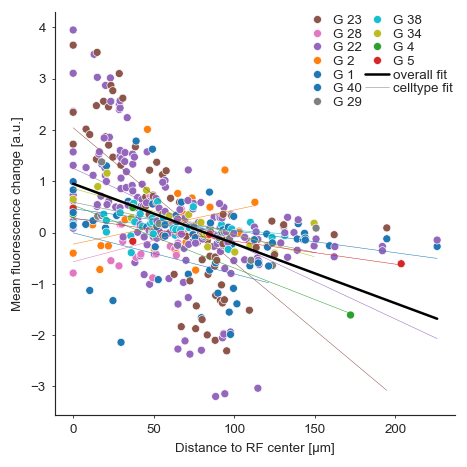

In [17]:
def dist_ct():
    field_key_list = dj_ut.fetch_all_fields_with_stm("circle")
    fig,axes = plt.subplots(1,1,sharex=True,sharey=True,figsize = plotter.figsize_from_frac(1/2,1/2))
    field_roi_ids = [(Offline2OnlineRoiId() & dict(stim_name="circle") & k).fetch("roi_id") for k in field_key_list]

    # roi_id_list = 12
    ax = dj_ut.wrapper_scatter_response_distance_celltype(
        field_key=field_key_list,
        roi_id_list=field_roi_ids,
        bsl_correction_method="median",
        measure="response_mean",
        stimulus_type="on_big",
        show_legend=True,
        ax = axes,
        cond2_value=None,
        plot_kwargs = {
            "single_group_fit_kwargs":{
                "order":1
            },
            "overall_fit_kwargs":{
                "order":1
            },
        }
    )
    return fig,ax
f,a = dist_ct()
plotter.tight_layout()
# save
f.savefig(os.path.join(FIGURE_PATH,f"Response_distance_celltype_bigcircle_allfields.svg"),format='svg')



In [12]:
def fetch_data():
        field_key_list = dj_ut.fetch_all_fields_with_stm("circle")
        field_roi_ids = [(Offline2OnlineRoiId() & dict(stim_name="circle") & k).fetch("roi_id") for k in field_key_list]
        full_df = dj_ut.fetch_and_format_data_for_snippet_analysis(
                field_key= field_key_list,
                roi_id_list = field_roi_ids, 
                bsl_correction_method="median",
                polarity="on",
                stimulus_type= "on_big",
                )
        return full_df
full_df = fetch_data()

No of fields passed: 3
Nr of rois per field: [21, 16, 5]
Dropping 168 rows with is_first_pres_of_stimulus == 1
Filtered rois_snippets_df to columns: ['roi_id', 'stimulus_type', 'single_snippet', 'single_snippet_t0', 'online_roi_id', 'cond2', 'single_snippet_bsl_corrected_median', 'distance']
Grouping by columns: ['roi_id', 'stimulus_type', 'distance'], reducing df cols over {'single_snippet', 'online_roi_id', 'single_snippet_t0', 'cond2', 'single_snippet_bsl_corrected_median'}
Number of unique groups: 1680
Averaged df over columns: ['single_snippet_bsl_corrected_median'], resulting df has 1680 rows. Differece in rows: 1680
output df col names: ['roi_id', 'stimulus_type', 'distance', 'single_snippet_bsl_corrected_median']
Dropping 320 rows with is_first_pres_of_stimulus == 1
Filtered rois_snippets_df to columns: ['roi_id', 'stimulus_type', 'single_snippet', 'single_snippet_t0', 'online_roi_id', 'cond2', 'single_snippet_bsl_corrected_median', 'distance']
Grouping by columns: ['roi_id', '

In [13]:
ci_df = su.bootstrap(full_df)
ci_df

analyzing for type 1
analyzing for type 2
analyzing for type 4
analyzing for type 5
analyzing for type 22
analyzing for type 23
analyzing for type 28
analyzing for type 29
analyzing for type 34
analyzing for type 38
analyzing for type 40


,celltype,low,high,poly_power
0,1,-0.938951,0.997584,0
1,1,-0.020406,0.002439,1
2,2,-0.642789,0.364622,0
3,2,-0.000526,0.012631,1
4,4,0.270552,2.538785,0
5,4,-0.055458,0.003613,1
6,5,-0.279335,0.475491,0
7,5,-0.017464,0.002929,1
8,22,0.955174,1.554927,0
9,22,-0.019158,-0.011350,1


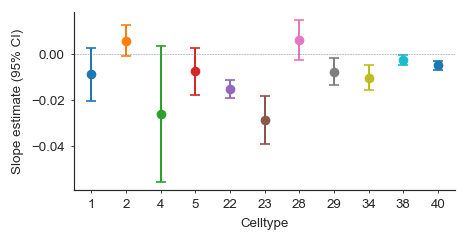

In [ ]:

df_plot = pu.make_plot_df(ci_df, only_order_n=1)
fig,ax = pu.plot_conf_intervals(df_plot,figsize = plotter.figsize_from_frac(1/2,1/4))
ax.set_ylabel("Slope estimate (95% CI)")
plotter.tight_layout()
#fig.savefig(os.path.join(FIGURE_PATH,f"Confidence_intervals_bootstrap_response_distance_celltype_bigcircle_allfields.svg"),format='svg')
